In [1]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import jsf as jsf
import gillespy2
import numpy as np
import time
import numpy as np

import pdb
from GillespieDirectMethod import gillespie_direct_method
from TauLeapingMethod import tau_leaping_method

%matplotlib widget


In [2]:

class SIRModel(gillespy2.Model):
    def __init__(self, initial_conditions=None, dt = 0.01, parameter_values=None):
        super().__init__(name="SIR_Model")
        
        # Parameters
        beta =  gillespy2.Parameter(name='beta',  expression=2/7)
        gamma = gillespy2.Parameter(name='gamma', expression=1/7)
        delta = gillespy2.Parameter(name='delta', expression=1/(365))  # Waning immunity rate
        mu =    gillespy2.Parameter(name='mu',    expression=1/(85*365))  # Birth rate
        kappa = gillespy2.Parameter(name='kappa', expression=1/(85*365))  # Death rate
        self.add_parameter([beta, gamma, delta, mu, kappa])
        
        # Initial conditions
        if initial_conditions is None:
            initial_conditions = {'S': 100000, 'I': 2, 'R': 0}
        
        # Species
        S = gillespy2.Species(name='S', initial_value=initial_conditions['S'])
        I = gillespy2.Species(name='I', initial_value=initial_conditions['I'])
        R = gillespy2.Species(name='R', initial_value=initial_conditions['R'])
        self.add_species([S, I, R])
        
        # Reactions
        infection =       gillespy2.Reaction(name='infection',       reactants={'S': 1, 'I': 1}, products={'I': 2},         propensity_function='beta*S*I/(S+I+R)')
        recovery =        gillespy2.Reaction(name='recovery',        reactants={'I': 1},         products={'R': 1},         rate=gamma)
        waning_immunity = gillespy2.Reaction(name='waning_immunity', reactants={'R': 1},         products={'S': 1},         rate=delta)
        birth_S =         gillespy2.Reaction(name='birth_S',         reactants={'S': 1},         products={'S': 2},         rate=mu)
        birth_I =         gillespy2.Reaction(name='birth_I',         reactants={'I': 1},         products={'S': 1, 'I': 1}, rate=mu)
        birth_R =         gillespy2.Reaction(name='birth_R',         reactants={'R': 1},         products={'S': 1, 'R': 1}, rate=mu)
        death_S =         gillespy2.Reaction(name='death_S',         reactants={'S': 1},         products={},               rate=kappa)
        death_I =         gillespy2.Reaction(name='death_I',         reactants={'I': 1},         products={},               rate=kappa)
        death_R =         gillespy2.Reaction(name='death_R',         reactants={'R': 1},         products={},               rate=kappa)
        self.add_reaction([infection, recovery, waning_immunity, birth_S, birth_I, birth_R, death_S, death_I, death_R])
        
        # Timespan
        self.timespan(np.linspace(0, 4*365, round(1+(4*365)/dt)))


# Placeholder functions for different simulation methods
def jsf_process(I, N, switch_th):
    # Implement the JSF process
    # Define the Parameters
    pbeta = 2/7
    pgamma = 1/7
    pwane = 1/(365)
    pmu =    1/(85*365)
    pkappa = 1/(85*365)

    # Define the final time
    t_max = 4*365
    # Define the stoichiometry
    reactant_matrix =[[1, 1, 0],
                    [0, 1, 0],
                    [1, 0, 0],
                    [0, 1, 0],
                    [0, 0, 1],
                    [1, 0, 0],
                    [0, 1, 0],
                    [0, 0, 1],
                    [0, 0, 1]]

    product_matrix = [[0, 2, 0],
                    [0, 0, 1],
                    [2, 0, 0],
                    [1, 1, 0],
                    [1, 0, 1],
                    [0, 0, 0],
                    [0, 0, 0],
                    [0, 0, 0],
                    [1, 0, 0]]

    # Define the rates
    rates = lambda x, t: [pbeta  * x[0] * x[1] / ( x[0] + x[1] + x[2] ),
                        pgamma * x[1],
                        pkappa * x[0],
                        pkappa * x[1],
                        pkappa * x[2],
                        pmu    * x[0],
                        pmu    * x[1],
                        pmu    * x[2],
                        pwane  * x[2]]

    stoich = {
            "nu": [ [a - b for a, b in zip(r1, r2)]
                    for r1, r2 in zip(product_matrix, reactant_matrix) ],
            "DoDisc": [0, 0, 0],
            "nuReactant": reactant_matrix,
            "nuProduct": product_matrix,
            }

#     switch_th = 3
    my_opts = {
                "EnforceDo": [0, 0, 0],
                "dt": 0.01,
                "SwitchingThreshold": [round(pow(10,switch_th)), round(pow(10,switch_th)), round(pow(10,switch_th))]
            }
    x0 = [N-I, I, 0]

    start_jsf = time.process_time()
    sim_jsf = jsf.jsf(x0, rates, stoich, t_max, config=my_opts, method="operator-splitting")
    finish_jsf = time.process_time()
    ellapsed_jsf = finish_jsf - start_jsf
    return ellapsed_jsf, sim_jsf

def tau_leaping(I, N, dtau = 0.01):
    # Implement the Tau leaping simulation
    # Define the Parameters
    pbeta = 2/7
    pgamma = 1/7
    pwane = 1/(365)
    pmu =    1/(85*365)
    pkappa = 1/(85*365)

    # Define the final time
    t_max = 4*365
    # Define the stoichiometry
    reactant_matrix =[[1, 1, 0],
                    [0, 1, 0],
                    [1, 0, 0],
                    [0, 1, 0],
                    [0, 0, 1],
                    [1, 0, 0],
                    [0, 1, 0],
                    [0, 0, 1],
                    [0, 0, 1]]

    product_matrix = [[0, 2, 0],
                    [0, 0, 1],
                    [2, 0, 0],
                    [1, 1, 0],
                    [1, 0, 1],
                    [0, 0, 0],
                    [0, 0, 0],
                    [0, 0, 0],
                    [1, 0, 0]]

    # Define the rates
    rates = lambda x, t: [pbeta  * x[0] * x[1] / ( x[0] + x[1] + x[2] ),
                        pgamma * x[1],
                        pkappa * x[0],
                        pkappa * x[1],
                        pkappa * x[2],
                        pmu    * x[0],
                        pmu    * x[1],
                        pmu    * x[2],
                        pwane  * x[2]]

    stoich = {
            "nu": [ [a - b for a, b in zip(r1, r2)]
                    for r1, r2 in zip(product_matrix, reactant_matrix) ],
            "DoDisc": [0, 0, 0],
            "nuReactant": reactant_matrix,
            "nuProduct": product_matrix,
            }

    switch_th = 3
    my_opts = {
                "EnforceDo": [0, 0, 0],
                "dt": 0.01,
                "SwitchingThreshold": [pow(10,switch_th), pow(10,switch_th), pow(10,switch_th)]
            }
    x0 = [N-I, I, 0]

    start_tau = time.process_time()
    sim_tau = tau_leaping_method(x0, rates, stoich, [0, t_max], options={"dt": dtau})
    finish_tau = time.process_time()
    ellapsed_tau = finish_tau - start_tau
    return ellapsed_tau, sim_tau


def gillespie(I, N):
    # Implement the Gillespie simulation
    # Define the Parameters
    pbeta = 2/7
    pgamma = 1/7
    pwane = 1/(365)
    pmu =    1/(85*365)
    pkappa = 1/(85*365)

    # Define the final time
    t_max = 4*365
    # Define the stoichiometry
    reactant_matrix =[[1, 1, 0],
                    [0, 1, 0],
                    [1, 0, 0],
                    [0, 1, 0],
                    [0, 0, 1],
                    [1, 0, 0],
                    [0, 1, 0],
                    [0, 0, 1],
                    [0, 0, 1]]

    product_matrix = [[0, 2, 0],
                    [0, 0, 1],
                    [2, 0, 0],
                    [1, 1, 0],
                    [1, 0, 1],
                    [0, 0, 0],
                    [0, 0, 0],
                    [0, 0, 0],
                    [1, 0, 0]]

    # Define the rates
    rates = lambda x, t: [pbeta  * x[0] * x[1] / ( x[0] + x[1] + x[2] ),
                        pgamma * x[1],
                        pkappa * x[0],
                        pkappa * x[1],
                        pkappa * x[2],
                        pmu    * x[0],
                        pmu    * x[1],
                        pmu    * x[2],
                        pwane  * x[2]]

    stoich = {
            "nu": [ [a - b for a, b in zip(r1, r2)]
                    for r1, r2 in zip(product_matrix, reactant_matrix) ],
            "DoDisc": [0, 0, 0],
            "nuReactant": reactant_matrix,
            "nuProduct": product_matrix,
            }
    x0 = [N-I, I, 0]
    
    start_gillespie = time.process_time()
    sim_gil = gillespie_direct_method(x0, rates, stoich, [0, t_max], options=None)
    finish_gillespie = time.process_time()
    ellapsed_gillespi = finish_gillespie - start_gillespie
    return ellapsed_gillespi, sim_gil


def jsf_process_ode(I, N):
    # Implement the JSF process
    # Define the Parameters
    pbeta = 2/7
    pgamma = 1/7
    pwane = 1/(365)
    pmu =    1/(85*365)
    pkappa = 1/(85*365)

    # Define the final time
    t_max = 20*365
    # Define the stoichiometry
    reactant_matrix =[[1, 1, 0],
                    [0, 1, 0],
                    [1, 0, 0],
                    [0, 1, 0],
                    [0, 0, 1],
                    [1, 0, 0],
                    [0, 1, 0],
                    [0, 0, 1],
                    [0, 0, 1]]

    product_matrix = [[0, 2, 0],
                    [0, 0, 1],
                    [2, 0, 0],
                    [1, 1, 0],
                    [1, 0, 1],
                    [0, 0, 0],
                    [0, 0, 0],
                    [0, 0, 0],
                    [1, 0, 0]]

    # Define the rates
    rates = lambda x, t: [pbeta  * x[0] * x[1] / ( x[0] + x[1] + x[2] ),
                        pgamma * x[1],
                        pkappa * x[0],
                        pkappa * x[1],
                        pkappa * x[2],
                        pmu    * x[0],
                        pmu    * x[1],
                        pmu    * x[2],
                        pwane  * x[2]]

    stoich = {
            "nu": [ [a - b for a, b in zip(r1, r2)]
                    for r1, r2 in zip(product_matrix, reactant_matrix) ],
            "DoDisc": [0, 0, 0],
            "nuReactant": reactant_matrix,
            "nuProduct": product_matrix,
            }

#     switch_th = 3
    my_opts = {
                "EnforceDo": [0, 0, 0],
                "dt": 0.01,
                "SwitchingThreshold": [0, 0, 0]
            }
    x0 = [N-I, I, 0]

    start_jsf = time.process_time()
    sim_jsf = jsf.jsf(x0, rates, stoich, t_max, config=my_opts, method="operator-splitting")
    finish_jsf = time.process_time()
    ellapsed_jsf = finish_jsf - start_jsf
    return ellapsed_jsf, sim_jsf

In [3]:
# Population sizes to test

population_sizes = []

numb_runs = 100

# track the time taken for each method

jsf_times_1 = []
jsf_times_3 = []
jsf_times_5 = []
gil_times = []

pop_numb = 13

# SIMULATE JSF AND GILLESPIE
# Main comparison
for ii in range(4, pop_numb):
    N0 = round( pow(10, ii*0.5) )
    population_sizes.append(N0)

    I0 = 10
    
    jsf_times_1_j = 0
    jsf_times_3_j = 0
    jsf_times_5_j = 0
    gil_times_j = 0

    progress = 0
    for i in range(numb_runs):
        jsf_time_1_i, jsf_sim = jsf_process(I0, (N0), 1)
        jsf_time_3_i, jsf_sim = jsf_process(I0, (N0), 3)
        jsf_time_5_i, jsf_sim = jsf_process(I0, (N0), 5)
        if (N0) <= 10**6:
            gil_time_i, gil_sim = gillespie(I0, (N0))
        else:
            gil_time_i = 10**-2
        
        jsf_times_1_j = jsf_times_1_j + jsf_time_1_i
        jsf_times_3_j = jsf_times_3_j + jsf_time_3_i
        jsf_times_5_j = jsf_times_5_j + jsf_time_5_i
        gil_times_j = gil_times_j + gil_time_i

        progress = (progress + 1)
        prog = round(progress/numb_runs * 100)
        print("|" + "-"*prog  + " "*(100-prog) + "| " + f"{prog}%", end="\r")

    jsf_times_1.append(jsf_times_1_j / numb_runs)
    jsf_times_3.append(jsf_times_3_j / numb_runs)
    jsf_times_5.append(jsf_times_5_j / numb_runs)
    gil_times.append(gil_times_j / numb_runs)

    
    print( '\n')
    print(f"Population size: {N0}")
    print(f"JSF-1: {jsf_times_1_j / numb_runs:.3f}s | JSF-3: {jsf_times_3_j / numb_runs:.3f}s | JSF-5: {jsf_times_5_j / numb_runs:.3f}s | Gillespie: {gil_times_j / numb_runs:.3f}s")
    print( '\n')


# SIMULATE HYBRID METHOD OF GILLESPY2
population_sizes = []

hyb_times_1 = []
hyb_times_2 = []
hyb_times_3 = []

# Main comparison loop
for ii in range(4, pop_numb):
    N0 = round( pow(10, ii*0.5) )
    population_sizes.append(N0)

    I0 = 10

    hyb_times_j_1 = 0
    hyb_times_j_2 = 0


    initial_conditions = {'S': round(N0)-I0, 'I': I0, 'R': 0}
    sir_model = SIRModel(initial_conditions=initial_conditions, dt=0.01)
    c_solver = gillespy2.TauHybridCSolver(model=sir_model)
    start_time = time.perf_counter()
    results = sir_model.run(solver=c_solver, number_of_trajectories=numb_runs)
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    elapsed_time_1 = elapsed_time / numb_runs
    hyb_times_1.append(elapsed_time_1)


    sir_model = SIRModel(initial_conditions=initial_conditions, dt=0.1)
    c_solver = gillespy2.TauHybridCSolver(model=sir_model)
    start_time = time.perf_counter()
    results = sir_model.run(solver=c_solver, number_of_trajectories=numb_runs)
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    elapsed_time_2 = elapsed_time / numb_runs
    hyb_times_2.append(elapsed_time_2)

    sir_model = SIRModel(initial_conditions=initial_conditions, dt=0.1)
    python_solver = gillespy2.TauHybridSolver(model=sir_model)
    start_time = time.perf_counter()
    results = sir_model.run(solver=python_solver, number_of_trajectories=numb_runs)
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    elapsed_time_3 = elapsed_time / numb_runs
    hyb_times_3.append(elapsed_time_3)
    
    print( '\n')
    print(f"Population size: {N0}")
    print(f"Tau-Hybrid-1: {elapsed_time_1:.3f}s | Tau-Hybrid-2: {elapsed_time_2:.3f}s | Tau-Hybrid-3: {elapsed_time_3:.3f}s")
    print( '\n')


# SIMULATE TAU LEAPING
population_sizes = []
# track the time taken for each method

tau_times_1 = []
tau_times_2 = []

# Main comparison loop
for ii in range(4, pop_numb):
    N0 = round( pow(10, ii*0.5) )
    population_sizes.append(N0)

    I0 = 10
    
    tau_times_j_1 = 0
    tau_times_j_2 = 0

    progress = 0
    for i in range(numb_runs):

        tau_time_i_1, tau_sim = tau_leaping(I0, (N0), 0.01)
        tau_times_j_1 = tau_times_j_1 + tau_time_i_1

        tau_time_i_1, tau_sim = tau_leaping(I0, (N0), 0.1)
        tau_times_j_2 = tau_times_j_2 + tau_time_i_1

        progress = (progress + 1)
        prog = round(progress/numb_runs * 100)
        print("|" + "-"*prog  + " "*(100-prog) + "| " + f"{prog}%", end="\r")


    tau_times_1.append(tau_times_j_1 / numb_runs)
    tau_times_2.append(tau_times_j_2 / numb_runs)
    
    print( '\n')
    print(f"Population size: {N0}")
    print(f"Tau-1: {tau_times_j_1 / numb_runs:.3f}s | Tau-2: {tau_times_j_2 / numb_runs:.3f}s")
    print( '\n')





|----------------------------------------------------------------------------------------------------| 100%

Population size: 100
JSF-1: 0.995s | JSF-3: 0.970s | JSF-5: 0.965s | Gillespie: 0.004s


|----------------------------------------------------------------------------------------------------| 100%

Population size: 316
JSF-1: 0.998s | JSF-3: 0.973s | JSF-5: 0.971s | Gillespie: 0.011s


|----------------------------------------------------------------------------------------------------| 100%

Population size: 1000
JSF-1: 0.996s | JSF-3: 0.986s | JSF-5: 0.985s | Gillespie: 0.035s


|----------------------------------------------------------------------------------------------------| 100%

Population size: 3162
JSF-1: 0.983s | JSF-3: 1.051s | JSF-5: 1.026s | Gillespie: 0.110s


|----------------------------------------------------------------------------------------------------| 100%

Population size: 10000
JSF-1: 0.955s | JSF-3: 1.063s | JSF-5: 1.174s | Gillespie: 0.379s


|-----

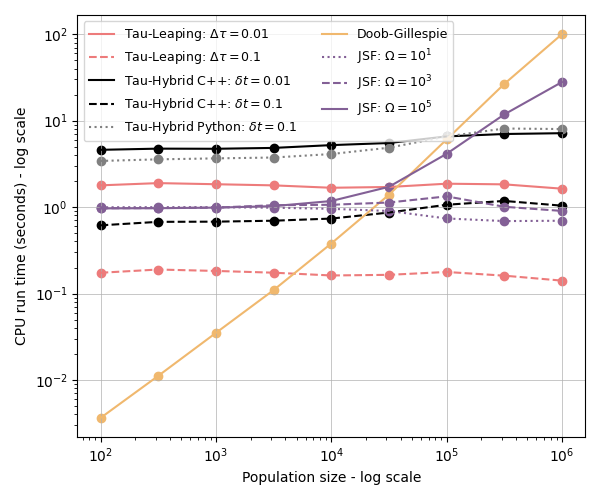

help


In [9]:
purple_colour = (131/255, 96/255, 150/255)
red_colour = (237/255, 123/255, 123/255)
yellow_colour = (240/255, 184/255, 110/255)

# Plot the results
plt.figure(figsize=(6, 5))

plt.grid(True,  linestyle="-", linewidth=0.5)


plt.scatter(population_sizes, tau_times_1,   color=red_colour)
plt.scatter(population_sizes, tau_times_2,   color=red_colour)
plt.scatter(population_sizes, hyb_times_1,   color='black')
plt.scatter(population_sizes, hyb_times_2,   color='black')
plt.scatter(population_sizes, hyb_times_3,   color='gray')
plt.scatter(population_sizes, gil_times, color=yellow_colour)
plt.scatter(population_sizes, jsf_times_1, color=purple_colour)
plt.scatter(population_sizes, jsf_times_3, color=purple_colour)
plt.scatter(population_sizes, jsf_times_5, color=purple_colour)

plt.plot(population_sizes, tau_times_1, '-', color=red_colour, label=r'Tau-Leaping: $\Delta \tau= 0.01$')
plt.plot(population_sizes, tau_times_2, '--',color=red_colour, label=r'Tau-Leaping: $\Delta \tau = 0.1$')
plt.plot(population_sizes, hyb_times_1, '-', color='black', label=r'Tau-Hybrid C++: $\delta t = 0.01$')
plt.plot(population_sizes, hyb_times_2, '--',color='black', label=r'Tau-Hybrid C++: $\delta t = 0.1$')
plt.plot(population_sizes, hyb_times_3, ':',color='gray', label=r'Tau-Hybrid Python: $\delta t = 0.1$')
plt.plot(population_sizes, gil_times,        color=yellow_colour, label='Doob-Gillespie')
plt.plot(population_sizes, jsf_times_1, ':', color=purple_colour, label=r'JSF: $\Omega = 10^1$')
plt.plot(population_sizes, jsf_times_3, '--',color=purple_colour, label=r'JSF: $\Omega = 10^3$')
plt.plot(population_sizes, jsf_times_5, '-', color=purple_colour, label=r'JSF: $\Omega = 10^5$')

plt.xlabel('Population size - log scale')
plt.ylabel('CPU run time (seconds) - log scale')
plt.yscale("log")
plt.xscale("log")

# plt.legend(ncol=1, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend(ncol=2, loc='upper left', fontsize=9)
plt.tight_layout()

# plt.ylim(3*10**-3, 1.5*10**2)

plt.show()

print('help')
# save the figure as a pdf
plt.savefig('cpu_time_comparison.pdf')


In [11]:
N0 = round( pow(10, 4) )
I0 = 10

tau_time_i_1, tau_sim_1 = tau_leaping(I0, (N0), 0.01)
tau_time_i_2, tau_sim_2 = tau_leaping(I0, (N0), 0.1)

jsf_time_1_i, jsf_sim_1 = jsf_process(I0, (N0), 1)
jsf_time_3_i, jsf_sim_3 = jsf_process(I0, (N0), 3)
jsf_time_5_i, jsf_sim_5 = jsf_process(I0, (N0), 5)

gil_time_i, gil_sim = gillespie(I0, (N0))



<>:5: SyntaxWarning: invalid escape sequence '\D'
<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\O'
<>:8: SyntaxWarning: invalid escape sequence '\O'
<>:9: SyntaxWarning: invalid escape sequence '\O'
<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\O'
<>:17: SyntaxWarning: invalid escape sequence '\O'
<>:18: SyntaxWarning: invalid escape sequence '\O'
<>:23: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:25: SyntaxWarning: invalid escape sequence '\O'
<>:26: SyntaxWarning: invalid escape sequence '\O'
<>:27: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\D'
<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\O'
<>:8: SyntaxWarning: invalid escape sequence '\O'
<>:9: SyntaxWarning: invalid escape sequ

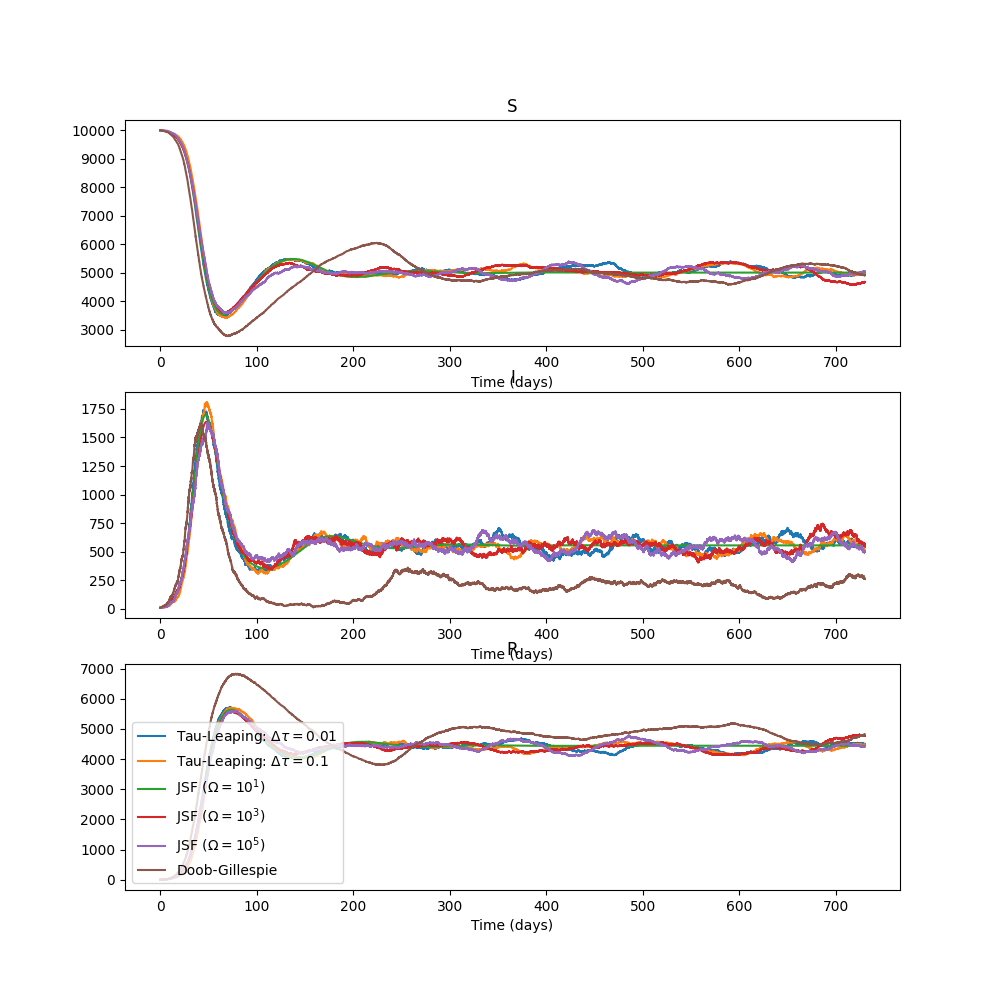

In [31]:

# plot the results in a subplot of size 3x1
fig, axs = plt.subplots(3, 1, figsize=(10, 10))

# Plot the results
axs[0].plot(tau_sim_1[1], tau_sim_1[0][0], label='Tau-Leaping: $\Delta \\tau = 0.01$')
axs[0].plot(tau_sim_2[1], tau_sim_2[0][0], label='Tau-Leaping: $\Delta \\tau = 0.1$')
axs[0].plot(jsf_sim_1[1], jsf_sim_1[0][0], label='JSF ($\Omega = 10^1$)')
axs[0].plot(jsf_sim_3[1], jsf_sim_3[0][0], label='JSF ($\Omega = 10^3$)')
axs[0].plot(jsf_sim_5[1], jsf_sim_5[0][0], label='JSF ($\Omega = 10^5$)')
axs[0].plot(gil_sim[1], gil_sim[0][0], label='Doob-Gillespie')
axs[0].set_title('S')
axs[0].set_xlabel('Time (days)')

axs[1].plot(tau_sim_1[1], tau_sim_1[0][1], label='Tau-Leaping: $\Delta \\tau = 0.01$')
axs[1].plot(tau_sim_2[1], tau_sim_2[0][1], label='Tau-Leaping: $\Delta \\tau = 0.1$')
axs[1].plot(jsf_sim_1[1], jsf_sim_1[0][1], label='JSF ($\Omega = 10^1$)')
axs[1].plot(jsf_sim_3[1], jsf_sim_3[0][1], label='JSF ($\Omega = 10^3$)')
axs[1].plot(jsf_sim_5[1], jsf_sim_5[0][1], label='JSF ($\Omega = 10^5$)')
axs[1].plot(gil_sim[1], gil_sim[0][1], label='Doob-Gillespie')
axs[1].set_title('I')
axs[1].set_xlabel('Time (days)')

axs[2].plot(tau_sim_1[1], tau_sim_1[0][2], label='Tau-Leaping: $\Delta \\tau = 0.01$')
axs[2].plot(tau_sim_2[1], tau_sim_2[0][2], label='Tau-Leaping: $\Delta \\tau = 0.1$')
axs[2].plot(jsf_sim_1[1], jsf_sim_1[0][2], label='JSF ($\Omega = 10^1$)')
axs[2].plot(jsf_sim_3[1], jsf_sim_3[0][2], label='JSF ($\Omega = 10^3$)')
axs[2].plot(jsf_sim_5[1], jsf_sim_5[0][2], label='JSF ($\Omega = 10^5$)')
axs[2].plot(gil_sim[1], gil_sim[0][2], label='Doob-Gillespie')
axs[2].set_title('R')
axs[2].set_xlabel('Time (days)')

plt.legend()
plt.show()


In [19]:
# Population sizes to test

numb_runs = 100

# track the time taken for each method

jsf_times = []

ThresholdSize = np.linspace(0, 5, 11).tolist()

# Main comparison loop
N0 = round( pow(10, 5) )
I0 = 10
for Thresh in ThresholdSize:
    
    jsf_times_i = 0
    progress = 0

    print( '\n')
    print(f"Threshold: {Thresh}")

    for i in range(numb_runs):
        jsf_time_1_i, jsf_sim = jsf_process(I0, (N0), Thresh)

        
        jsf_times_i = jsf_times_i + jsf_time_1_i

        progress = (progress + 1)
        prog = round(progress/numb_runs * 100)
        print("|" + "-"*prog  + " "*(100-prog) + "| " + f"{prog}%", end="\r")

    jsf_times.append(jsf_times_i / numb_runs)

    
    print( '\n')
    print(f"JSF-1: {jsf_times_i / numb_runs:.3f}s")




Threshold: 0.0
|----------------------------------------------------------------------------------------------------| 100%

JSF-1: 0.671s


Threshold: 0.5
|----------------------------------------------------------------------------------------------------| 100%

JSF-1: 0.671s


Threshold: 1.0
|----------------------------------------------------------------------------------------------------| 100%

JSF-1: 0.717s


Threshold: 1.5
|----------------------------------------------------------------------------------------------------| 100%

JSF-1: 0.870s


Threshold: 2.0
|----------------------------------------------------------------------------------------------------| 100%

JSF-1: 0.900s


Threshold: 2.5
|----------------------------------------------------------------------------------------------------| 100%

JSF-1: 0.943s


Threshold: 3.0
|----------------------------------------------------------------------------------------------------| 100%

JSF-1: 1.359s


Threshold: 3.5
|--

In [29]:
N0 = round( pow(10, 5) )
I0 = 10
time_jsf, jsf_results = jsf_process_ode(I0, N0)


<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_19408/2816125394.py:16: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log_{10}(\Omega)$')


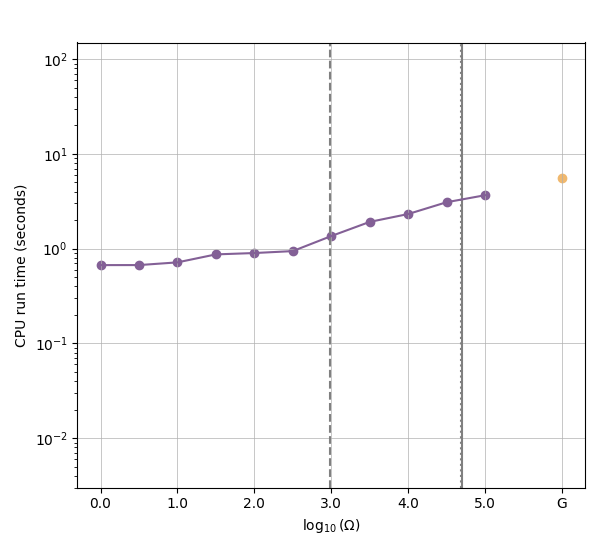

In [ ]:

# plot jsf_times against ThresholdSize
plt.figure(figsize=(6, 5.5))


#plot constant value in x-axis
plt.axvline(x=np.log10(jsf_results[0][0][-1]), color='grey', linestyle='-')
plt.axvline(x=np.log10(jsf_results[0][1][-1]), color='grey', linestyle='--')
plt.axvline(x=np.log10(jsf_results[0][2][-1]), color='grey', linestyle=':')

plt.scatter(np.log10(population_sizes[6])+1, gil_times[6], color=yellow_colour)

plt.scatter(ThresholdSize, jsf_times, color=purple_colour)
plt.plot(ThresholdSize, jsf_times, color=purple_colour)


plt.xlabel('$\log_{10}(\Omega)$')
plt.ylabel('CPU run time (seconds)')
plt.tight_layout()

plt.yscale("log")
plt.ylim(3*10**-3, 1.5*10**2)

tick_labels = ThresholdSize + ["G"]
xticks = ThresholdSize + [6]

plt.xticks(ticks=xticks, labels=tick_labels)

plt.grid(True, which='major', linestyle="-", linewidth=0.5)
plt.gca().xaxis.set_major_locator(plt.MultipleLocator(1))

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust the layout to ensure the ylabel is visible
plt.show()

# save the figure as a pdf
plt.savefig('jsf_threshold_comparison.pdf')